# CSF Ground Segmentation on Multi-Sensor LiDAR

**BEP Thesis — Phase 1: Ground Segmentation**

This notebook performs ground segmentation on a single timestamp from a ROS2 .mcap recording. Three LiDAR sensors mounted on a bike (one front-facing M1P + two rear-mounted spinning Helios) are fused into a common `base_link` frame, then ground points are extracted using the Cloth Simulation Filter (CSF).

**Pipeline:**
1. Settings & helper functions
2. Load a single frame from each of the 3 LiDAR topics
3. Apply TF transforms to align all sensors in `base_link`
4. Merge into a single point cloud
5. Run CSF ground filter
6. Visualize: 2D top view, 2D side view, 3D interactive
7. Save outputs (.ply files)


In [1]:
# ============================================================
# CELL 1 — Settings & imports
# ============================================================

import numpy as np
import open3d as o3d
import os, sys, struct
import matplotlib.pyplot as plt
from mcap.reader import make_reader
from mcap_ros2.decoder import DecoderFactory

# ── Input file ────────────────────────────────────────────
INPUT_FILE  = r"D:\Rosbags\01 mei\14_40_00\rosbag\rosbag_0.mcap"
FRAME_INDEX = 418   # frame number to process

# ── LiDAR topics ──────────────────────────────────────────
LIDAR_TOPICS = [
    "/rslidar/M1P_deskewed",
    "/rslidar/helios_R",
    "/rslidar/helios_L",
]

# ── Sensor TF transforms (read from /tf_static via Foxglove) ─
SENSOR_TRANSFORMS = {
    "/rslidar/M1P_deskewed":  {"translation": [ 0.800,  0.000, 0.876], "rotation_rpy_deg": [0.1, -1.7,  1.7]},
    "/rslidar/helios_R":      {"translation": [-0.743, -0.243, 0.857], "rotation_rpy_deg": [2.4, -2.6, -179.9]},
    "/rslidar/helios_L":      {"translation": [-0.745,  0.191, 0.876], "rotation_rpy_deg": [3.5, -2.1,  179.9]},
}

# ── CSF parameters (fixed for thesis) ─────────────────────
CSF_CLOTH_RESOLUTION = 0.3    # cloth grid size in meters
CSF_SLOPE_SMOOTH     = True   # True = gentle slopes, False = steep terrain
CSF_THRESHOLD        = 0.1    # max distance from cloth to count as ground (m)

# ── Output paths ──────────────────────────────────────────
OUTPUT_DIR = r"C:\Users\JRepa\OneDrive - Delft University of Technology\Documenten\02. TU Delft\2025-2026\BEP\Data\Ground points"
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUT_GROUND_PLY  = os.path.join(OUTPUT_DIR, f"frame{FRAME_INDEX}_ground.ply")
OUT_MERGED_PLY  = os.path.join(OUTPUT_DIR, f"frame{FRAME_INDEX}_merged.ply")
OUT_TOP_VIEW    = os.path.join(OUTPUT_DIR, f"frame{FRAME_INDEX}_topview.png")
OUT_SIDE_VIEW   = os.path.join(OUTPUT_DIR, f"frame{FRAME_INDEX}_sideview.png")

print("Settings loaded.")
print(f"Input:  {INPUT_FILE}")
print(f"Frame:  {FRAME_INDEX}")
print(f"Output: {OUTPUT_DIR}")


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Settings loaded.
Input:  D:\Rosbags\01 mei\14_40_00\rosbag\rosbag_0.mcap
Frame:  418
Output: C:\Users\JRepa\OneDrive - Delft University of Technology\Documenten\02. TU Delft\2025-2026\BEP\Data\Ground points


In [2]:
# ============================================================
# CELL 1b — Frame estimator from timestamp (optional)
# Paste a Foxglove timestamp here to find the matching frame.
# Updates FRAME_INDEX automatically.
# Leave USE_TIMESTAMP = False to use the manual FRAME_INDEX from Cell 1.
# ============================================================

USE_TIMESTAMP    = True
TARGET_TIMESTAMP = 1777639270.466376996   # paste from Foxglove

REFERENCE_TOPIC = "/rslidar/M1P_deskewed"

if USE_TIMESTAMP:
    print(f"Scanning timestamps from '{REFERENCE_TOPIC}'...")
    timestamps = []
    with open(INPUT_FILE, "rb") as f:
        reader = make_reader(f, decoder_factories=[DecoderFactory()])
        for schema, channel, message, ros_msg in reader.iter_decoded_messages(topics=[REFERENCE_TOPIC]):
            timestamps.append(message.log_time / 1e9)

    timestamps = np.array(timestamps)
    print(f"  Found {len(timestamps)} frames")
    print(f"  Recording: {timestamps[0]:.3f}  →  {timestamps[-1]:.3f}  ({timestamps[-1]-timestamps[0]:.1f}s)")

    diffs        = np.abs(timestamps - TARGET_TIMESTAMP)
    frame_match  = int(np.argmin(diffs))
    closest_time = timestamps[frame_match]
    error_ms     = abs(closest_time - TARGET_TIMESTAMP) * 1000

    print(f"\n  Target:  {TARGET_TIMESTAMP:.3f}")
    print(f"  Closest: {closest_time:.3f}  (error: {error_ms:.1f} ms)")
    print(f"  → Frame: {frame_match}")

    FRAME_INDEX = frame_match

    # Update output paths to use new frame number
    OUT_GROUND_PLY  = os.path.join(OUTPUT_DIR, f"frame{FRAME_INDEX}_ground.ply")
    OUT_MERGED_PLY  = os.path.join(OUTPUT_DIR, f"frame{FRAME_INDEX}_merged.ply")
    OUT_TOP_VIEW    = os.path.join(OUTPUT_DIR, f"frame{FRAME_INDEX}_topview.png")
    OUT_SIDE_VIEW   = os.path.join(OUTPUT_DIR, f"frame{FRAME_INDEX}_sideview.png")

    print(f"\n  FRAME_INDEX = {FRAME_INDEX}  ← updated automatically")
else:
    print(f"Using manual FRAME_INDEX = {FRAME_INDEX}")

Scanning timestamps from '/rslidar/M1P_deskewed'...
  Found 2752 frames
  Recording: 1777639202.825  →  1777639500.323  (297.5s)

  Target:  1777639270.466
  Closest: 1777639270.428  (error: 38.3 ms)
  → Frame: 627

  FRAME_INDEX = 627  ← updated automatically


In [3]:
# ============================================================
# CELL 2 — Helper functions
# ============================================================

def rpy_deg_to_rotation_matrix(roll_deg, pitch_deg, yaw_deg):
    """Convert roll/pitch/yaw (degrees) to a 3x3 rotation matrix."""
    r, p, y = np.radians(roll_deg), np.radians(pitch_deg), np.radians(yaw_deg)
    Rx = np.array([[1,0,0],[0,np.cos(r),-np.sin(r)],[0,np.sin(r),np.cos(r)]])
    Ry = np.array([[np.cos(p),0,np.sin(p)],[0,1,0],[-np.sin(p),0,np.cos(p)]])
    Rz = np.array([[np.cos(y),-np.sin(y),0],[np.sin(y),np.cos(y),0],[0,0,1]])
    return Rz @ Ry @ Rx

def transform_points(points, translation, rotation_rpy_deg):
    """Apply rigid transform to Nx3 point array."""
    R = rpy_deg_to_rotation_matrix(*rotation_rpy_deg)
    t = np.array(translation, dtype=np.float32)
    return (points @ R.T).astype(np.float32) + t

def pointcloud2_to_numpy(msg):
    """Vectorized parser: ROS PointCloud2 message -> Nx3 numpy array (x,y,z)."""
    field_map = {f.name: f for f in msg.fields}
    if not all(k in field_map for k in ("x","y","z")):
        return None
    x_off, y_off, z_off = field_map["x"].offset, field_map["y"].offset, field_map["z"].offset
    step, n = msg.point_step, msg.width * msg.height
    raw = np.frombuffer(bytes(msg.data), dtype=np.uint8)
    raw_2d = raw[:n * step].reshape(n, step)
    x = raw_2d[:, x_off:x_off+4].view(np.float32).reshape(-1)
    y = raw_2d[:, y_off:y_off+4].view(np.float32).reshape(-1)
    z = raw_2d[:, z_off:z_off+4].view(np.float32).reshape(-1)
    xyz = np.stack([x, y, z], axis=1)
    return xyz[np.isfinite(xyz).all(axis=1)]

def load_lidar_frame(filepath, topic, frame_index):
    """Load a single frame from an mcap topic. Returns Nx3 numpy or None."""
    with open(filepath, "rb") as f:
        reader = make_reader(f, decoder_factories=[DecoderFactory()])
        idx = 0
        for schema, channel, message, ros_msg in reader.iter_decoded_messages(topics=[topic]):
            if idx == frame_index:
                return pointcloud2_to_numpy(ros_msg)
            idx += 1
    return None

print("Helper functions defined.")


Helper functions defined.


In [4]:
# ============================================================
# CELL 3 — Load frame from each sensor
# ============================================================

print(f"Loading frame {FRAME_INDEX} from {len(LIDAR_TOPICS)} sensors...\n")

raw_clouds = {}
for topic in LIDAR_TOPICS:
    pts = load_lidar_frame(INPUT_FILE, topic, FRAME_INDEX)
    if pts is None or len(pts) == 0:
        print(f"  {topic:<35s}  NO DATA")
    else:
        raw_clouds[topic] = pts
        print(f"  {topic:<35s}  {len(pts):>8,} points")

if not raw_clouds:
    raise RuntimeError("No data loaded for any topic. Check FRAME_INDEX and topic names.")


Loading frame 627 from 3 sensors...

  /rslidar/M1P_deskewed                  58,140 points
  /rslidar/helios_R                      38,968 points
  /rslidar/helios_L                      37,808 points


In [5]:
# ============================================================
# CELL 4 — Transform sensors into base_link
# ============================================================

transformed_clouds = {}
for topic, pts in raw_clouds.items():
    tf = SENSOR_TRANSFORMS[topic]
    transformed_clouds[topic] = transform_points(pts, tf["translation"], tf["rotation_rpy_deg"])
    print(f"  Transformed {topic}: {len(transformed_clouds[topic]):,} points")

print(f"\nAll sensors aligned in base_link frame.")


  Transformed /rslidar/M1P_deskewed: 58,140 points
  Transformed /rslidar/helios_R: 38,968 points
  Transformed /rslidar/helios_L: 37,808 points

All sensors aligned in base_link frame.


In [6]:
# ============================================================
# CELL 5 — Merge all sensors into one cloud
# ============================================================

merged_cloud_full = np.vstack(list(transformed_clouds.values()))  # keep full version
merged_cloud      = merged_cloud_full.copy()                       # working copy
print(f"Merged point cloud: {len(merged_cloud):,} points\n")
print(f"Bounding box (base_link frame):")
print(f"  X: {merged_cloud[:,0].min():>7.2f}  →  {merged_cloud[:,0].max():>7.2f} m")
print(f"  Y: {merged_cloud[:,1].min():>7.2f}  →  {merged_cloud[:,1].max():>7.2f} m")
print(f"  Z: {merged_cloud[:,2].min():>7.2f}  →  {merged_cloud[:,2].max():>7.2f} m")

Merged point cloud: 134,916 points

Bounding box (base_link frame):
  X:  -91.73  →    91.17 m
  Y:  -95.66  →    86.23 m
  Z:   -8.44  →    24.86 m


In [7]:
# ============================================================
# CELL 6 — Run CSF ground filter
# ============================================================
import CSF

# Crop FIRST, then run CSF on the cropped data
X_RANGE = 20.0
Y_RANGE = 1.0

x_mask    = np.abs(merged_cloud[:, 0]) <= X_RANGE
y_mask    = np.abs(merged_cloud[:, 1]) <= Y_RANGE
crop_mask = x_mask & y_mask
merged_cloud = merged_cloud[crop_mask]
print(f"Cropped to X ±{X_RANGE}m, Y ±{Y_RANGE}m: {len(merged_cloud):,} points\n")

print(f"Running CSF with fixed parameters:")
print(f"  cloth_resolution = {CSF_CLOTH_RESOLUTION} m")
print(f"  slope_smooth     = {CSF_SLOPE_SMOOTH}")
print(f"  threshold        = {CSF_THRESHOLD} m\n")

csf = CSF.CSF()
csf.params.bSloopSmooth     = CSF_SLOPE_SMOOTH
csf.params.cloth_resolution = CSF_CLOTH_RESOLUTION
csf.params.threshold        = CSF_THRESHOLD
csf.setPointCloud(merged_cloud)

ground_idx     = CSF.VecInt()
non_ground_idx = CSF.VecInt()
csf.do_filtering(ground_idx, non_ground_idx)

ground_points     = merged_cloud[np.array(list(ground_idx))]
non_ground_points = merged_cloud[np.array(list(non_ground_idx))]

pct_g  = 100 * len(ground_points)     / len(merged_cloud)
pct_ng = 100 * len(non_ground_points) / len(merged_cloud)

print(f"Results:")
print(f"  Ground:     {len(ground_points):>8,} points  ({pct_g:>5.1f}%)")
print(f"  Non-ground: {len(non_ground_points):>8,} points  ({pct_ng:>5.1f}%)")

Cropped to X ±20.0m, Y ±1.0m: 34,697 points

Running CSF with fixed parameters:
  cloth_resolution = 0.3 m
  slope_smooth     = True
  threshold        = 0.1 m

Results:
  Ground:       26,910 points  ( 77.6%)
  Non-ground:    7,787 points  ( 22.4%)


In [8]:
print(f"merged_cloud size: {len(merged_cloud):,}")
print(f"ground_points size: {len(ground_points):,}")
print(f"non_ground_points size: {len(non_ground_points):,}")
print(f"Y range of ground: {ground_points[:,1].min():.2f} → {ground_points[:,1].max():.2f}")
print(f"Y range of non_ground: {non_ground_points[:,1].min():.2f} → {non_ground_points[:,1].max():.2f}")

merged_cloud size: 34,697
ground_points size: 26,910
non_ground_points size: 7,787
Y range of ground: -1.00 → 1.00
Y range of non_ground: -0.99 → 1.00


Saved: C:\Users\JRepa\OneDrive - Delft University of Technology\Documenten\02. TU Delft\2025-2026\BEP\Data\Ground points\frame627_topview.png


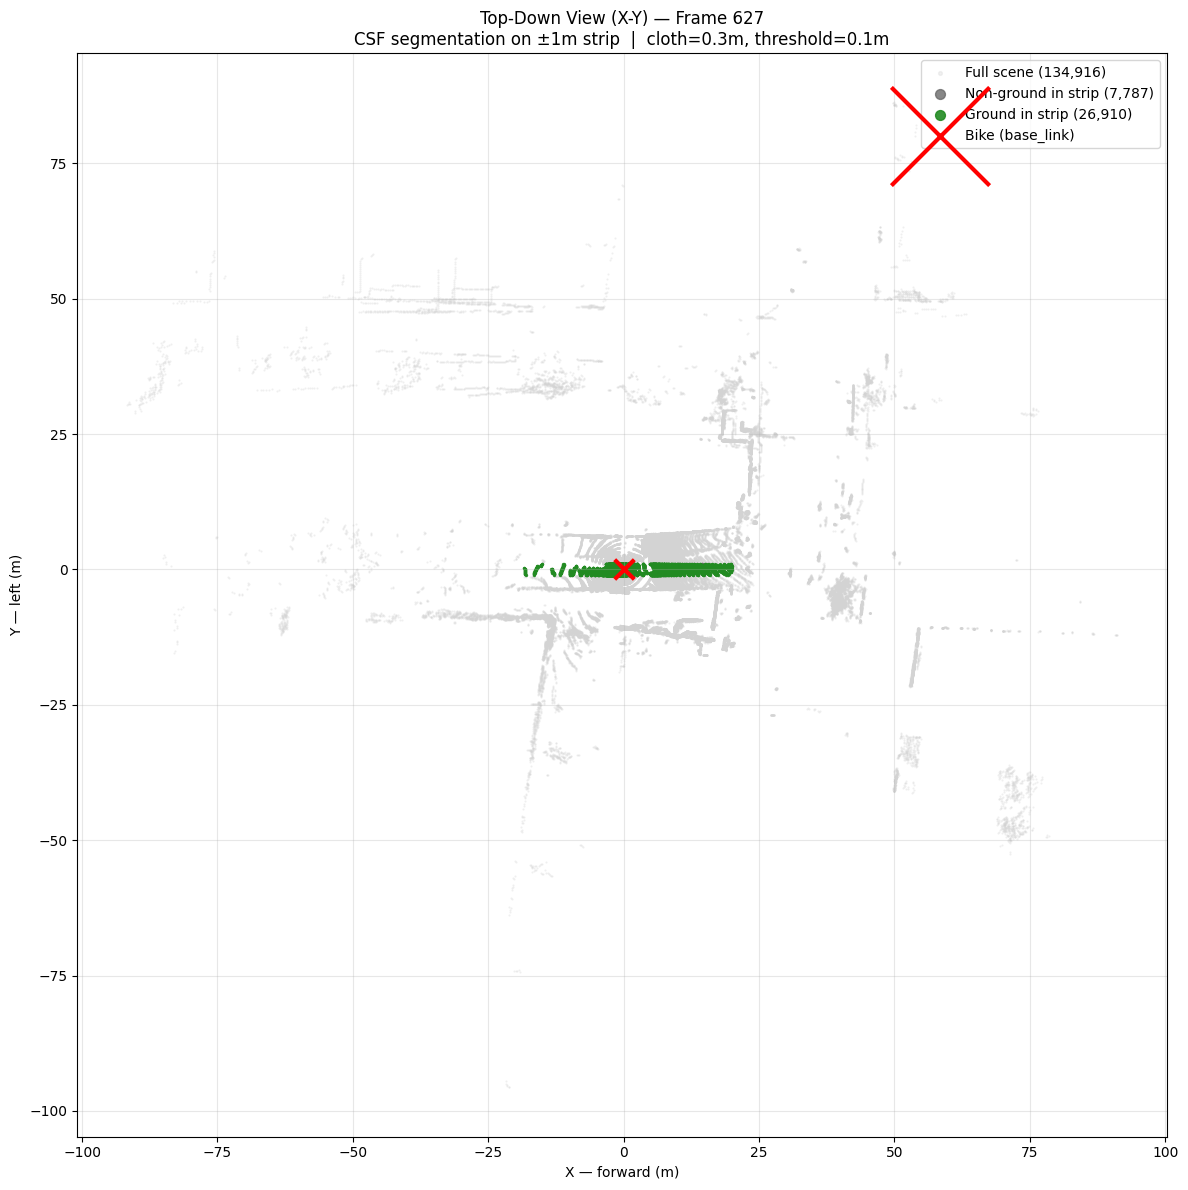

In [9]:
# ============================================================
# CELL 7 — 2D top-down view (X-Y plane)
# ============================================================
plt.close('all')

fig, ax = plt.subplots(figsize=(12, 12))

# Faded full cloud as background context
ax.scatter(merged_cloud_full[:, 0], merged_cloud_full[:, 1],
           s=0.3, c='lightgray', alpha=0.3, label=f'Full scene ({len(merged_cloud_full):,})')

# Highlighted strip with segmentation
ax.scatter(non_ground_points[:, 0], non_ground_points[:, 1],
           s=2, c='dimgray', alpha=0.8, label=f'Non-ground in strip ({len(non_ground_points):,})')
ax.scatter(ground_points[:, 0], ground_points[:, 1],
           s=2, c='forestgreen', alpha=0.9, label=f'Ground in strip ({len(ground_points):,})')

ax.scatter(0, 0, s=200, c='red', marker='x', linewidths=3, label='Bike (base_link)', zorder=10)

ax.set_xlabel("X — forward (m)")
ax.set_ylabel("Y — left (m)")
ax.set_title(f"Top-Down View (X-Y) — Frame {FRAME_INDEX}\n"
             f"CSF segmentation on ±1m strip  |  cloth={CSF_CLOTH_RESOLUTION}m, threshold={CSF_THRESHOLD}m")
ax.legend(loc='upper right', markerscale=5)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(OUT_TOP_VIEW, dpi=150, bbox_inches='tight')
print(f"Saved: {OUT_TOP_VIEW}")
plt.show()

Saved: C:\Users\JRepa\OneDrive - Delft University of Technology\Documenten\02. TU Delft\2025-2026\BEP\Data\Ground points\frame627_bev_comparison.png


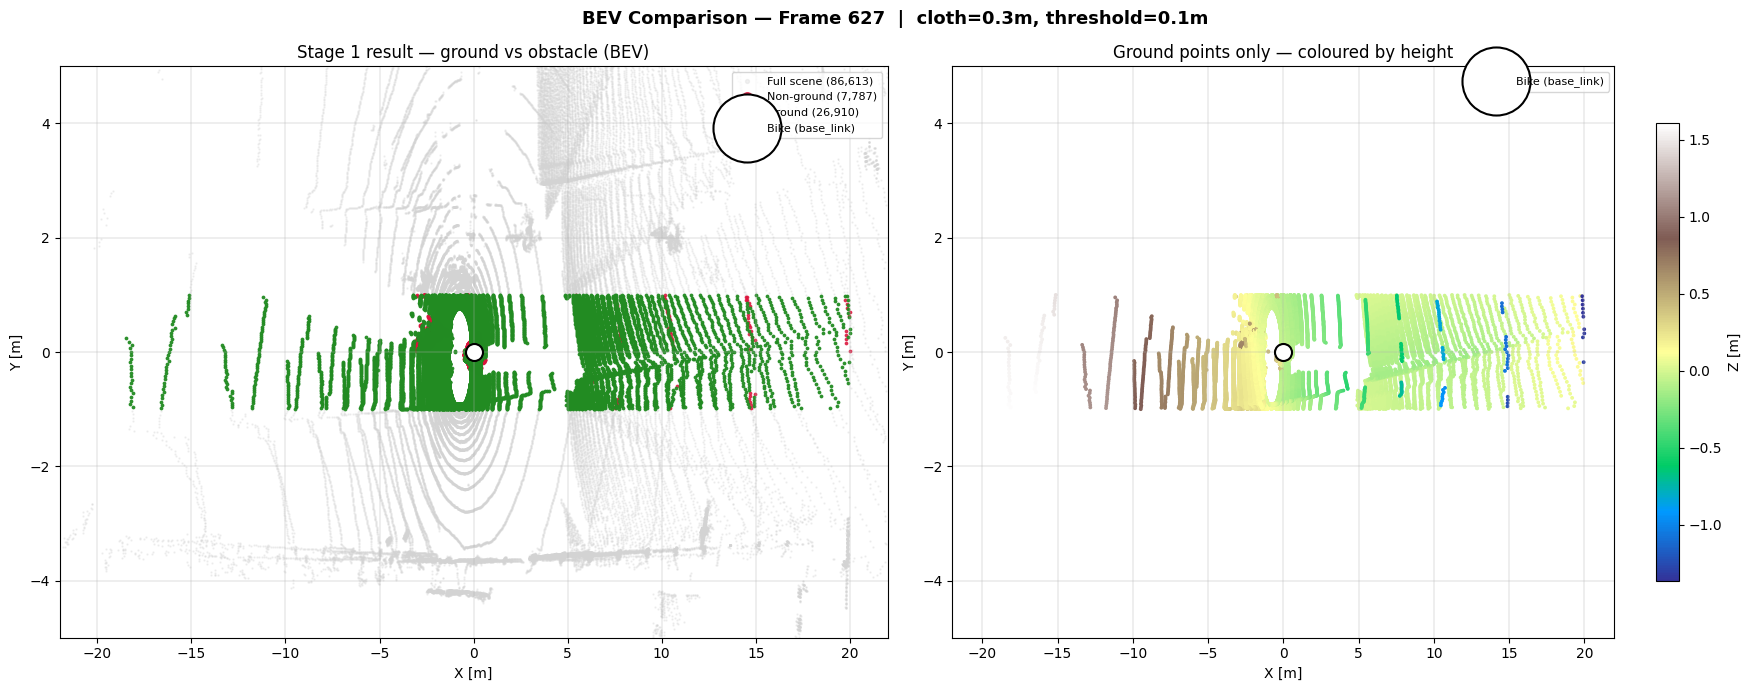

In [10]:
# ============================================================
# CELL 7b — BEV side-by-side: segmentation result vs ground-only (height-coloured)
# Matches Patchwork++ style: fixed axis limits, no forced equal aspect
# ============================================================
plt.close('all')

# ── Axis limits: match the CSF crop with a small margin ─────
X_LIM = (-22, 22)
Y_LIM = (-5, 5)     # wider than the ±1m crop so the strip isn't a hairline

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── LEFT: segmentation result ────────────────────────────────
ax = axes[0]

# Clip the background cloud to the view window before plotting
bg_mask = (
    (merged_cloud_full[:, 0] >= X_LIM[0]) & (merged_cloud_full[:, 0] <= X_LIM[1]) &
    (merged_cloud_full[:, 1] >= Y_LIM[0]) & (merged_cloud_full[:, 1] <= Y_LIM[1])
)
bg_clip = merged_cloud_full[bg_mask]

ax.scatter(bg_clip[:, 0], bg_clip[:, 1],
           s=0.5, c='lightgray', alpha=0.3, rasterized=True, label=f'Full scene ({len(bg_clip):,})')
ax.scatter(non_ground_points[:, 0], non_ground_points[:, 1],
           s=3, c='crimson', alpha=0.8, rasterized=True, label=f'Non-ground ({len(non_ground_points):,})')
ax.scatter(ground_points[:, 0], ground_points[:, 1],
           s=3, c='forestgreen', alpha=0.9, rasterized=True, label=f'Ground ({len(ground_points):,})')
ax.scatter(0, 0, s=150, c='white', marker='o', edgecolors='black', linewidths=1.5,
           label='Bike (base_link)', zorder=10)

ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_title("Stage 1 result — ground vs obstacle (BEV)")
ax.set_xlim(*X_LIM)
ax.set_ylim(*Y_LIM)
ax.legend(loc='upper right', markerscale=4, fontsize=8)
ax.grid(True, lw=0.3)

# ── RIGHT: ground only, coloured by height ───────────────────
ax = axes[1]

sc = ax.scatter(ground_points[:, 0], ground_points[:, 1],
                c=ground_points[:, 2], s=3, cmap='terrain',
                rasterized=True)
plt.colorbar(sc, ax=ax, label="Z [m]", shrink=0.8)
ax.scatter(0, 0, s=150, c='white', marker='o', edgecolors='black', linewidths=1.5,
           label='Bike (base_link)', zorder=10)

ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_title("Ground points only — coloured by height")
ax.set_xlim(*X_LIM)
ax.set_ylim(*Y_LIM)
ax.legend(loc='upper right', markerscale=4, fontsize=8)
ax.grid(True, lw=0.3)

fig.suptitle(
    f"BEV Comparison — Frame {FRAME_INDEX}  |  "
    f"cloth={CSF_CLOTH_RESOLUTION}m, threshold={CSF_THRESHOLD}m",
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
OUT_BEV_COMPARISON = os.path.join(OUTPUT_DIR, f"frame{FRAME_INDEX}_bev_comparison.png")
plt.savefig(OUT_BEV_COMPARISON, dpi=150, bbox_inches='tight')
print(f"Saved: {OUT_BEV_COMPARISON}")
plt.show()

Saved: C:\Users\JRepa\OneDrive - Delft University of Technology\Documenten\02. TU Delft\2025-2026\BEP\Data\Ground points\frame627_sideview.png


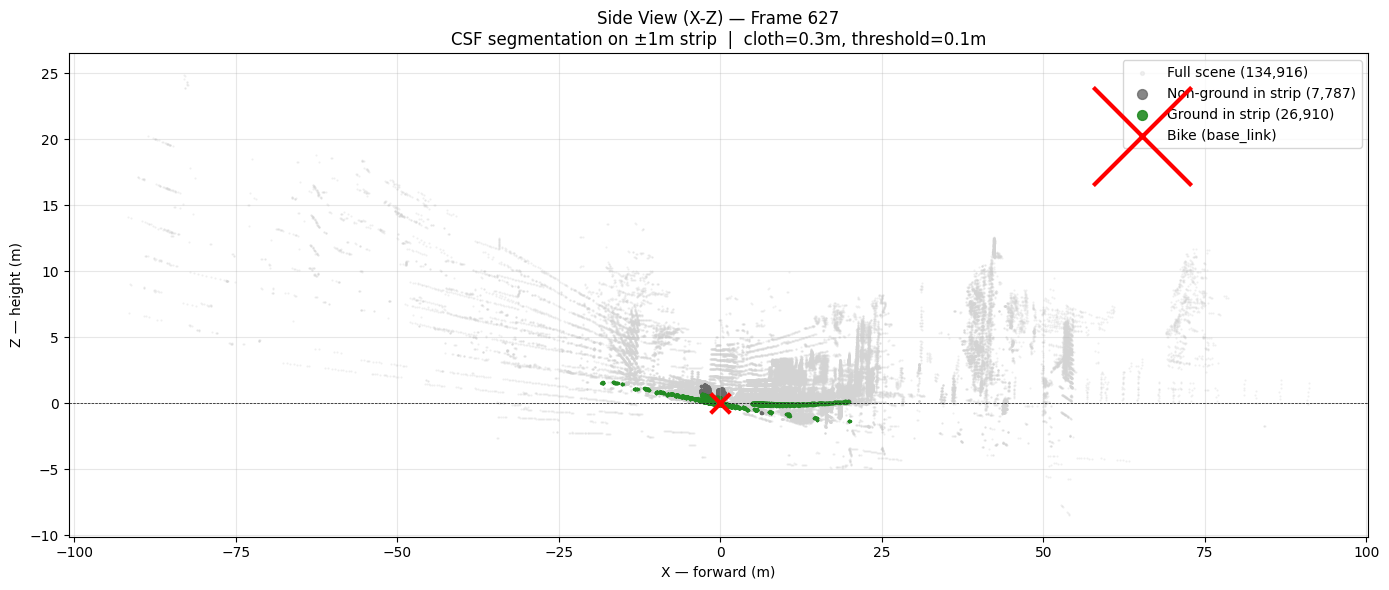

In [11]:
# ============================================================
# CELL 8 — 2D side view (X-Z plane)
# ============================================================
plt.close('all')

fig, ax = plt.subplots(figsize=(14, 6))

# Faded full cloud
ax.scatter(merged_cloud_full[:, 0], merged_cloud_full[:, 2],
           s=0.3, c='lightgray', alpha=0.3, label=f'Full scene ({len(merged_cloud_full):,})')

# Highlighted strip
ax.scatter(non_ground_points[:, 0], non_ground_points[:, 2],
           s=2, c='dimgray', alpha=0.8, label=f'Non-ground in strip ({len(non_ground_points):,})')
ax.scatter(ground_points[:, 0], ground_points[:, 2],
           s=2, c='forestgreen', alpha=0.9, label=f'Ground in strip ({len(ground_points):,})')

ax.scatter(0, 0, s=200, c='red', marker='x', linewidths=3, label='Bike (base_link)', zorder=10)

ax.set_xlabel("X — forward (m)")
ax.set_ylabel("Z — height (m)")
ax.set_title(f"Side View (X-Z) — Frame {FRAME_INDEX}\n"
             f"CSF segmentation on ±1m strip  |  cloth={CSF_CLOTH_RESOLUTION}m, threshold={CSF_THRESHOLD}m")
ax.legend(loc='upper right', markerscale=5)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig(OUT_SIDE_VIEW, dpi=150, bbox_inches='tight')
print(f"Saved: {OUT_SIDE_VIEW}")
plt.show()

In [12]:
# ============================================================
# CELL 9 — Interactive 3D viewer
# Opens a separate window. Close it (Q or X) to continue.
# Controls: left-drag = rotate | scroll = zoom | right-drag = pan
# ============================================================

pcd_ground = o3d.geometry.PointCloud()
pcd_ground.points = o3d.utility.Vector3dVector(ground_points)
pcd_ground.paint_uniform_color([0.13, 0.55, 0.13])  # forest green

pcd_non_ground = o3d.geometry.PointCloud()
pcd_non_ground.points = o3d.utility.Vector3dVector(non_ground_points)
pcd_non_ground.paint_uniform_color([0.5, 0.5, 0.5])  # gray

# Coordinate frame at bike origin
axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=1.0, origin=[0,0,0])

print(f"Opening 3D viewer — Frame {FRAME_INDEX}")
print("  Green = ground   |   Gray = non-ground   |   Coordinate frame at bike")
print("  Close window to continue.")

o3d.visualization.draw_geometries(
    [pcd_ground, pcd_non_ground, axis],
    window_name=f"CSF Ground Segmentation — Frame {FRAME_INDEX}",
    width=1400, height=900,
)


Opening 3D viewer — Frame 627
  Green = ground   |   Gray = non-ground   |   Coordinate frame at bike
  Close window to continue.


In [13]:
# ============================================================
# CELL 10 — Save outputs (.ply and .bin)
# ============================================================

# .ply — ground points
o3d.io.write_point_cloud(OUT_GROUND_PLY, pcd_ground)
print(f"Saved ground (.ply):  {OUT_GROUND_PLY}")

# .ply — full merged cloud
pcd_merged = o3d.geometry.PointCloud()
pcd_merged.points = o3d.utility.Vector3dVector(merged_cloud)
o3d.io.write_point_cloud(OUT_MERGED_PLY, pcd_merged)
print(f"Saved merged (.ply):  {OUT_MERGED_PLY}")

# .bin — ground points (KITTI-style float32 x,y,z,intensity)
OUT_GROUND_BIN = os.path.join(OUTPUT_DIR, f"frame{FRAME_INDEX}_ground.bin")
ground_with_intensity = np.zeros((len(ground_points), 4), dtype=np.float32)
ground_with_intensity[:, :3] = ground_points.astype(np.float32)
ground_with_intensity[:,  3] = 0.0  # placeholder intensity (not tracked in pipeline)
ground_with_intensity.tofile(OUT_GROUND_BIN)
print(f"Saved ground (.bin):  {OUT_GROUND_BIN}")

print(f"\n{'='*60}")
print(f"  CSF segmentation complete for frame {FRAME_INDEX}")
print(f"{'='*60}")
print(f"  Ground points:     {len(ground_points):>8,} ({100*len(ground_points)/len(merged_cloud):.1f}%)")
print(f"  Non-ground points: {len(non_ground_points):>8,} ({100*len(non_ground_points)/len(merged_cloud):.1f}%)")
print(f"  Outputs in:        {OUTPUT_DIR}")

Saved ground (.ply):  C:\Users\JRepa\OneDrive - Delft University of Technology\Documenten\02. TU Delft\2025-2026\BEP\Data\Ground points\frame627_ground.ply
Saved merged (.ply):  C:\Users\JRepa\OneDrive - Delft University of Technology\Documenten\02. TU Delft\2025-2026\BEP\Data\Ground points\frame627_merged.ply
Saved ground (.bin):  C:\Users\JRepa\OneDrive - Delft University of Technology\Documenten\02. TU Delft\2025-2026\BEP\Data\Ground points\frame627_ground.bin

  CSF segmentation complete for frame 627
  Ground points:       26,910 (77.6%)
  Non-ground points:    7,787 (22.4%)
  Outputs in:        C:\Users\JRepa\OneDrive - Delft University of Technology\Documenten\02. TU Delft\2025-2026\BEP\Data\Ground points
